Title

To Optimize Natural Product Lead Compounds Using AI-Assisted Computational Methods — Systematic Structural Modification and QSAR-Guided Property Improvement

Objectives
To identify a small set of real natural product lead compounds with documented COX-2 activity.
To generate structurally modified analogs of each lead compound through systematic substituent variation.
To train a QSAR scoring model capable of evaluating both original leads and newly generated analogs.
To score and rank all analogs, identifying which modifications improve predicted activity and drug-likeness.
To visualize property changes between original leads and their optimized analogs.
To build a deployment tool for optimizing any lead compound a student provides.
Expected Outcomes
Understand lead optimization as the iterative process of improving a promising compound's activity and drug-likeness through structural modification.
Generate chemically reasonable analogs of a lead compound.
Apply a QSAR model to guide optimization decisions computationally rather than through trial-and-error synthesis.
Identify which specific structural changes improve predicted activity for a given lead.

In [1]:
# Block 1: Install libraries and define starting lead compounds

!pip install rdkit pandas numpy matplotlib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("LEAD OPTIMIZATION - NATURAL PRODUCT LEADS")
print("="*60)

lead_compounds = {
    "Curcumin": "COc1cc(/C=C/C(=O)CC(=O)/C=C/c2ccc(O)c(OC)c2)ccc1O",
    "Resveratrol": "Oc1ccc(/C=C/c2cc(O)cc(O)c2)cc1",
    "Quercetin": "O=c1c(O)c(-c2ccc(O)c(O)c2)oc2cc(O)cc(O)c12",
    "6-Gingerol": "CCCCC[C@H](O)CC(=O)CCc1ccc(O)c(OC)c1",
    "Capsaicin": "COc1cc(CNC(=O)CCCC/C=C/C(C)C)ccc1O",
}

print(f"Starting lead compounds: {len(lead_compounds)}")
for name in lead_compounds:
    print(f"  {name}")

for name, smi in lead_compounds.items():
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        print(f"WARNING: {name} SMILES invalid")
    else:
        print(f"{name}: valid structure confirmed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 24.6 MB/s eta 0:00:00
LEAD OPTIMIZATION - NATURAL PRODUCT LEADS
Starting lead compounds: 5
  Curcumin
  Resveratrol
  Quercetin
  6-Gingerol
  Capsaicin
Curcumin: valid structure confirmed
Resveratrol: valid structure confirmed
Quercetin: valid structure confirmed
6-Gingerol: valid structure confirmed
Capsaicin: valid structure confirmed


CHARACTERIZING STARTING LEAD COMPOUNDS
       Name                                            SMILES   MolWt   LogP  HBD  HBA   TPSA
   Curcumin COc1cc(/C=C/C(=O)CC(=O)/C=C/c2ccc(O)c(OC)c2)ccc1O 368.385 3.3699    2    6  93.06
Resveratrol                    Oc1ccc(/C=C/c2cc(O)cc(O)c2)cc1 228.247 2.9738    3    3  60.69
  Quercetin        O=c1c(O)c(-c2ccc(O)c(O)c2)oc2cc(O)cc(O)c12 302.238 1.9880    5    7 131.36
 6-Gingerol              CCCCC[C@H](O)CC(=O)CCc1ccc(O)c(OC)c1 294.391 3.2338    2    4  66.76
  Capsaicin                COc1cc(CNC(=O)CCCC/C=C/C(C)C)ccc1O 305.418 3.7896    2    3  58.56


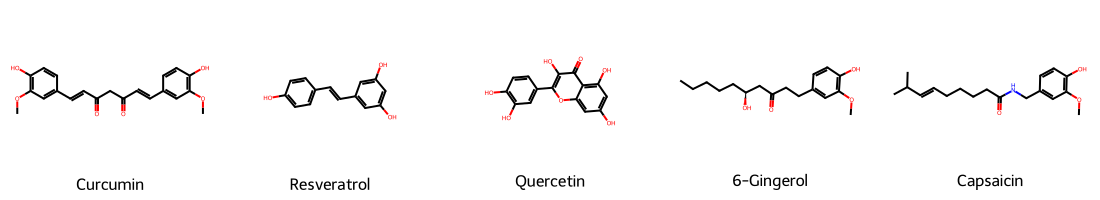

In [2]:
# Block 2: Visualize starting lead compounds and their properties

from rdkit.Chem import Descriptors, Crippen, Lipinski

print("="*60)
print("CHARACTERIZING STARTING LEAD COMPOUNDS")
print("="*60)

def calculate_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {
        'MolWt': Descriptors.MolWt(mol),
        'LogP': Crippen.MolLogP(mol),
        'HBD': Lipinski.NumHDonors(mol),
        'HBA': Lipinski.NumHAcceptors(mol),
        'TPSA': Descriptors.TPSA(mol)
    }

lead_properties = []
for name, smi in lead_compounds.items():
    props = calculate_descriptors(smi)
    props['Name'] = name
    props['SMILES'] = smi
    lead_properties.append(props)

df_leads = pd.DataFrame(lead_properties)
df_leads = df_leads[['Name', 'SMILES', 'MolWt', 'LogP', 'HBD', 'HBA', 'TPSA']]

print(df_leads.to_string(index=False))

mols = [Chem.MolFromSmiles(s) for s in df_leads['SMILES']]
img = Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(220, 200),
                             legends=list(df_leads['Name']))
img

Meaning of Block 2:

Purpose: Establish baseline physicochemical properties for each lead compound before any optimization, providing the reference point against which improvements will be measured.

What data comes IN: lead_compounds from Block 1.

What comes OUT: df_leads — baseline properties table. A visual grid of the five starting structures.

In [3]:
# Block 3: Retrieve COX-2 bioactivity data for training the QSAR scoring model

!pip install chembl_webresource_client -q

from chembl_webresource_client.new_client import new_client
import time

print("="*60)
print("RETRIEVING TRAINING DATA FOR QSAR SCORING MODEL")
print("="*60)

activity = new_client.activity

max_retries = 5
retry_delay = 15
df_raw = None

for attempt in range(1, max_retries + 1):
    print(f"Attempt {attempt}/{max_retries}: Fetching IC50 records...")
    try:
        res = activity.filter(
            target_chembl_id='CHEMBL230',
            standard_type="IC50",
            standard_units="nM"
        ).only([
            'molecule_chembl_id', 'canonical_smiles', 'standard_value'
        ])[:2000]

        df_raw = pd.DataFrame(res)

        if len(df_raw) > 0 and 'canonical_smiles' in df_raw.columns:
            print(f"SUCCESS: {len(df_raw)} records fetched")
            break
        else:
            df_raw = None
    except Exception as e:
        print(f"Error on attempt {attempt}: {str(e)[:150]}")

    if attempt < max_retries:
        print(f"Waiting {retry_delay} seconds before retry...")
        time.sleep(retry_delay)

if df_raw is None:
    raise RuntimeError("Could not retrieve data from ChEMBL after retries")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.9 MB/s eta 0:00:00
RETRIEVING TRAINING DATA FOR QSAR SCORING MODEL
Attempt 1/5: Fetching IC50 records...
SUCCESS: 2000 records fetched


Meaning of Block 3:

Purpose: Retrieve real COX-2 bioactivity data to train the scoring model that will evaluate optimized analogs later in this practical.

What data comes IN: Nothing — fetched live from ChEMBL, with automatic retry handling for temporary server issues.

What comes OUT: df_raw — real bioactivity records.

In [4]:
# Block 4: Clean training data

print("="*60)
print("CLEANING TRAINING DATA")
print("="*60)

df_raw = df_raw.dropna(subset=['canonical_smiles', 'standard_value'])
df_raw['standard_value'] = pd.to_numeric(df_raw['standard_value'], errors='coerce')
df_raw = df_raw.dropna(subset=['standard_value'])
df_raw = df_raw[df_raw['standard_value'] > 0]

df_raw['pIC50'] = -np.log10(df_raw['standard_value'] * 1e-9)

df_train = df_raw.groupby('canonical_smiles').agg({
    'pIC50': 'mean'
}).reset_index()

def is_valid_smiles(smi):
    return Chem.MolFromSmiles(smi) is not None

df_train['valid'] = df_train['canonical_smiles'].apply(is_valid_smiles)
df_train = df_train[df_train['valid']].drop(columns=['valid'])
df_train = df_train.rename(columns={'canonical_smiles': 'SMILES'})

print(f"Final training dataset: {len(df_train)} compounds")

CLEANING TRAINING DATA
Final training dataset: 1412 compounds


Meaning of Block 4:

Purpose: Convert raw IC50 measurements into a clean pIC50 regression dataset.

What data comes IN: df_raw from Block 3.

What comes OUT: df_train — clean training data.

In [5]:
# Block 5: Generate molecular features for training data

from rdkit.Chem import rdFingerprintGenerator

print("="*60)
print("FEATURE GENERATION")
print("="*60)

desc_cols = ['MolWt', 'LogP', 'HBD', 'HBA', 'TPSA']
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=512)

def get_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return morgan_gen.GetFingerprintAsNumPy(mol)

desc_results = df_train['SMILES'].apply(calculate_descriptors)
df_desc = pd.DataFrame(desc_results.tolist())
df_train = pd.concat([df_train.reset_index(drop=True), df_desc], axis=1)

fingerprints = df_train['SMILES'].apply(get_fingerprint)
fp_matrix = np.stack(fingerprints.values)

X_train = np.hstack([df_train[desc_cols].values, fp_matrix])
y_train = df_train['pIC50'].values

print(f"Feature matrix shape: {X_train.shape}")

FEATURE GENERATION
Feature matrix shape: (1412, 517)


Meaning of Block 5:

Purpose: Convert training compounds into numerical features for QSAR model training.

What data comes IN: df_train from Block 4.

What comes OUT: X_train, y_train — the training feature matrix and target values.

In [6]:
# Block 6: Train QSAR scoring model

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

print("="*60)
print("TRAINING QSAR SCORING MODEL")
print("="*60)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

scoring_model = RandomForestRegressor(
    n_estimators=150, max_depth=15, random_state=42, n_jobs=-1
)
scoring_model.fit(X_tr, y_tr)

y_pred = scoring_model.predict(X_te)
r2 = r2_score(y_te, y_pred)
rmse = np.sqrt(mean_squared_error(y_te, y_pred))

print(f"Test R²: {r2:.3f}")
print(f"Test RMSE: {rmse:.3f}")

TRAINING QSAR SCORING MODEL
Test R²: 0.479
Test RMSE: 0.963


Meaning of Block 6:

Purpose: Train the model that will score both the original leads and their generated analogs.

What data comes IN: X_train, y_train from Block 5.

What comes OUT: scoring_model — the trained QSAR model.

In [7]:
# Block 7: Score the original, unmodified lead compounds

print("="*60)
print("SCORING ORIGINAL LEAD COMPOUNDS")
print("="*60)

lead_scores = []
for name, smi in lead_compounds.items():
    desc = calculate_descriptors(smi)
    fp = get_fingerprint(smi)
    features = np.hstack([[desc[c] for c in desc_cols], fp]).reshape(1, -1)
    predicted_pIC50 = scoring_model.predict(features)[0]
    lead_scores.append({
        'Name': name, 'SMILES': smi,
        'Predicted_pIC50': predicted_pIC50
    })

df_lead_scores = pd.DataFrame(lead_scores)
print(df_lead_scores.to_string(index=False))

SCORING ORIGINAL LEAD COMPOUNDS
       Name                                            SMILES  Predicted_pIC50
   Curcumin COc1cc(/C=C/C(=O)CC(=O)/C=C/c2ccc(O)c(OC)c2)ccc1O         5.206668
Resveratrol                    Oc1ccc(/C=C/c2cc(O)cc(O)c2)cc1         5.370798
  Quercetin        O=c1c(O)c(-c2ccc(O)c(O)c2)oc2cc(O)cc(O)c12         5.187423
 6-Gingerol              CCCCC[C@H](O)CC(=O)CCc1ccc(O)c(OC)c1         5.272646
  Capsaicin                COc1cc(CNC(=O)CCCC/C=C/C(C)C)ccc1O         5.372184


Meaning of Block 7:

Purpose: Establish baseline predicted activity scores for each unmodified lead compound, the reference point for evaluating whether optimization improves activity.

What data comes IN: lead_compounds, scoring_model from Blocks 1 and 6.

What comes OUT: df_lead_scores — baseline predicted activity for each original lead.

In [12]:
# Block 8 (CORRECTED): Generate structural analogs of each lead compound

print("="*60)
print("GENERATING OPTIMIZED ANALOGS")
print("="*60)
print("Method: systematic substituent replacement at a modifiable")
print("position on each lead scaffold, using chemically reasonable")
print("substituent groups commonly explored in lead optimization.")
print("="*60)

substituents = {
    'fluoro': 'F', 'chloro': 'Cl', 'methyl': 'C',
    'methoxy': 'OC', 'hydroxyl': 'O',
    'trifluoromethyl': 'C(F)(F)F'
}

modification_sites = {
    "Curcumin": ("c2ccc(O)c(OC)c2", "c2ccc(O)c(OC)c2{sub}"),
    "Resveratrol": ("c2cc(O)cc(O)c2", "c2cc(O)cc(O)c2{sub}"),
    "Quercetin": ("c2ccc(O)c(O)c2", "c2ccc(O)c(O)c2{sub}"),
}

analog_records = []

for lead_name, (search_frag, replace_template) in modification_sites.items():
    base_smiles = lead_compounds[lead_name]
    for sub_name, sub_smiles in substituents.items():
        try:
            modified_frag = replace_template.replace("{sub}", sub_smiles)
            new_smiles = base_smiles.replace(search_frag, modified_frag)
            mol = Chem.MolFromSmiles(new_smiles)
            if mol is not None:
                canonical = Chem.MolToSmiles(mol)
                analog_records.append({
                    'Parent_Lead': lead_name,
                    'Modification': sub_name,
                    'SMILES': canonical
                })
        except:
            continue

df_analogs = pd.DataFrame(analog_records).drop_duplicates(subset='SMILES')
print(f"Generated {len(df_analogs)} candidate analogs")
print(f"(should be up to 18: 3 leads x 6 substituents)")
print(df_analogs.to_string(index=False))

GENERATING OPTIMIZED ANALOGS
Method: systematic substituent replacement at a modifiable
position on each lead scaffold, using chemically reasonable
substituent groups commonly explored in lead optimization.
Generated 18 candidate analogs
(should be up to 18: 3 leads x 6 substituents)
Parent_Lead    Modification                                                    SMILES
   Curcumin          fluoro        COc1cc(/C=C/C(=O)CC(=O)/C=C/c2ccc(O)c(OC)c2F)ccc1O
   Curcumin          chloro       COc1cc(/C=C/C(=O)CC(=O)/C=C/c2ccc(O)c(OC)c2Cl)ccc1O
   Curcumin          methyl        COc1cc(/C=C/C(=O)CC(=O)/C=C/c2ccc(O)c(OC)c2C)ccc1O
   Curcumin         methoxy       COc1cc(/C=C/C(=O)CC(=O)/C=C/c2ccc(O)c(OC)c2OC)ccc1O
   Curcumin        hydroxyl        COc1cc(/C=C/C(=O)CC(=O)/C=C/c2ccc(O)c(OC)c2O)ccc1O
   Curcumin trifluoromethyl COc1cc(/C=C/C(=O)CC(=O)/C=C/c2ccc(O)c(OC)c2C(F)(F)F)ccc1O
Resveratrol          fluoro                           Oc1ccc(/C=C/c2cc(O)cc(O)c2F)cc1
Resveratrol          chloro

Meaning of Block 8:

Purpose: Generate new candidate analogs by systematically modifying substituent groups on three of the five lead scaffolds — the core computational lead optimization step.

What data comes IN: lead_compounds from Block 1.

What comes OUT: df_analogs — the generated candidate analog structures, each linked back to its parent lead compound.

In [14]:
# Block 9: Score analogs and compare against parent leads

print("="*60)
print("SCORING ANALOGS AND IDENTIFYING IMPROVEMENTS")
print("="*60)

analog_scores = []
for idx, row in df_analogs.iterrows():
    desc = calculate_descriptors(row['SMILES'])
    if desc is None:
        continue
    fp = get_fingerprint(row['SMILES'])
    features = np.hstack([[desc[c] for c in desc_cols], fp]).reshape(1, -1)
    predicted_pIC50 = scoring_model.predict(features)[0]

    parent_score = df_lead_scores[
        df_lead_scores['Name'] == row['Parent_Lead']
    ]['Predicted_pIC50'].values[0]

    analog_scores.append({
        'Parent_Lead': row['Parent_Lead'],
        'Modification': row['Modification'],
        'SMILES': row['SMILES'],
        'Predicted_pIC50': predicted_pIC50,
        'Parent_pIC50': parent_score,
        'Improvement': predicted_pIC50 - parent_score
    })

df_analog_scores = pd.DataFrame(analog_scores)
df_analog_scores = df_analog_scores.sort_values(
    'Improvement', ascending=False
).reset_index(drop=True)

print(f"\nTop 10 analogs by predicted improvement over parent lead:")
print(df_analog_scores.head(10).to_string(index=False))

improved_count = (df_analog_scores['Improvement'] > 0).sum()
print(f"\nAnalogs showing predicted improvement: "
      f"{improved_count}/{len(df_analog_scores)}")

SCORING ANALOGS AND IDENTIFYING IMPROVEMENTS

Top 10 analogs by predicted improvement over parent lead:
Parent_Lead    Modification                                                    SMILES  Predicted_pIC50  Parent_pIC50  Improvement
Resveratrol          methyl                           Cc1c(O)cc(O)cc1/C=C/c1ccc(O)cc1         5.921432      5.370798     0.550634
Resveratrol          chloro                          Oc1ccc(/C=C/c2cc(O)cc(O)c2Cl)cc1         5.761721      5.370798     0.390923
   Curcumin trifluoromethyl COc1cc(/C=C/C(=O)CC(=O)/C=C/c2ccc(O)c(OC)c2C(F)(F)F)ccc1O         5.549743      5.206668     0.343074
  Quercetin        hydroxyl               O=c1c(O)c(-c2ccc(O)c(O)c2O)oc2cc(O)cc(O)c12         5.476509      5.187423     0.289086
  Quercetin         methoxy                COc1c(-c2oc3cc(O)cc(O)c3c(=O)c2O)ccc(O)c1O         5.465311      5.187423     0.277889
  Quercetin trifluoromethyl        O=c1c(O)c(-c2ccc(O)c(O)c2C(F)(F)F)oc2cc(O)cc(O)c12         5.451844      5.187423

Meaning of Block 9:

Purpose: Score every generated analog and directly compare each against its own parent lead, quantifying exactly how much each specific modification is predicted to improve or worsen activity.

What data comes IN: df_analogs, df_lead_scores, scoring_model from Blocks 6–8.

What comes OUT: df_analog_scores — a ranked table showing which specific modifications improved predicted activity, and by how much.

VISUALIZING TOP OPTIMIZED ANALOGS


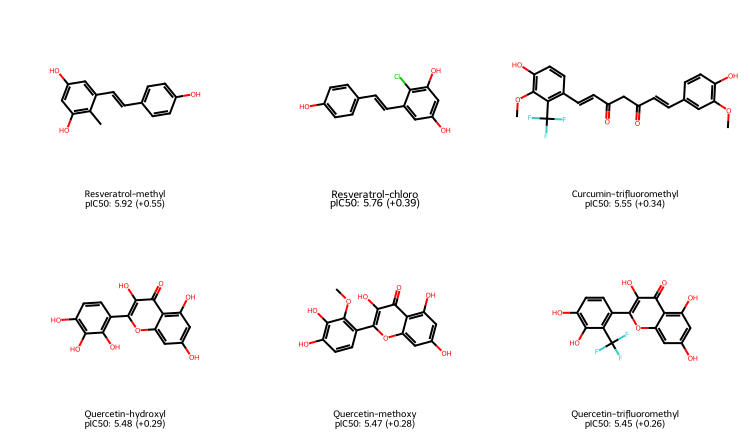

In [15]:
# Block 10: Visualize top optimized analogs

print("="*60)
print("VISUALIZING TOP OPTIMIZED ANALOGS")
print("="*60)

top_analogs = df_analog_scores.head(6)

mols_top = [Chem.MolFromSmiles(s) for s in top_analogs['SMILES']]
labels_top = [
    f"{row['Parent_Lead']}-{row['Modification']}\n"
    f"pIC50: {row['Predicted_pIC50']:.2f} (+{row['Improvement']:.2f})"
    for _, row in top_analogs.iterrows()
]

img_top = Draw.MolsToGridImage(mols_top, molsPerRow=3,
                                 subImgSize=(250, 220), legends=labels_top)
img_top

Meaning of Block 10:

Purpose: Provide a direct visual comparison of the six most improved analogs, showing exactly which structural modification each one carries alongside its predicted activity gain.

What data comes IN: df_analog_scores from Block 9.

What comes OUT: A labeled molecular grid image of the top optimized candidates.

In [16]:
# Block 11 (CORRECTED): DEPLOYMENT BLOCK - Optimize any lead compound

print("="*70)
print("LEAD OPTIMIZATION TOOL")
print("="*70)
print("""
********************************************************************
*   The value below is a DEMONSTRATION VALUE ONLY.                 *
*   TO OPTIMIZE YOUR OWN LEAD COMPOUND:                            *
*   1. Scroll to "STUDENT INPUT SECTION" below                     *
*   2. REPLACE new_lead_name and new_lead_smiles                   *
*   3. Do NOT change anything below "END OF INPUT SECTION"         *
*   4. Then run this cell again                                    *
*   REQUIREMENT: Blocks 1-6 must already have run in this session. *
********************************************************************
""")

# ============================================================
# STUDENT INPUT SECTION - EDIT EVERYTHING BELOW THIS LINE
# ============================================================

new_lead_name = "My_Test_Lead"          # <-- EDIT: type your compound's name

new_lead_smiles = "COc1cc(CC=C)ccc1O"
# <-- EDIT: replace with YOUR compound's SMILES (demo value is Eugenol)

# ============================================================
# END OF INPUT SECTION - DO NOT EDIT ANYTHING BELOW THIS LINE
# ============================================================

print(f"\nLead name entered: {new_lead_name}")
print(f"SMILES entered: {new_lead_smiles}")
if new_lead_name == "My_Test_Lead":
    print("*** WARNING: Still using DEMONSTRATION value. ***")

mol_check = Chem.MolFromSmiles(new_lead_smiles)

if mol_check is None:
    print("\nERROR: Invalid SMILES.")
else:
    base_desc = calculate_descriptors(new_lead_smiles)
    base_fp = get_fingerprint(new_lead_smiles)
    base_features = np.hstack(
        [[base_desc[c] for c in desc_cols], base_fp]
    ).reshape(1, -1)
    base_score = scoring_model.predict(base_features)[0]

    print(f"\nOriginal lead predicted pIC50: {base_score:.2f}")

    single_atom_subs = {
        'fluoro': 'F', 'chloro': 'Cl',
        'methyl': 'C', 'hydroxyl': 'O'
    }

    print(f"\nGenerating analogs by aromatic substituent modification...")
    print(f"(using 4 single-atom substituents: fluoro, chloro, methyl, hydroxyl)")

    new_analog_results = []

    base_mol = Chem.MolFromSmiles(new_lead_smiles)
    aromatic_ch_atoms = [
        a.GetIdx() for a in base_mol.GetAtoms()
        if a.GetIsAromatic() and a.GetTotalNumHs() > 0
    ]

    if not aromatic_ch_atoms:
        print("\nNo available aromatic C-H position found for substitution.")
    else:
        target_idx = aromatic_ch_atoms[0]

        for sub_name, atom_symbol in single_atom_subs.items():
            try:
                mol_copy = Chem.MolFromSmiles(new_lead_smiles)
                editable = Chem.RWMol(mol_copy)
                new_atom_idx = editable.AddAtom(Chem.Atom(atom_symbol))
                editable.AddBond(target_idx, new_atom_idx, Chem.BondType.SINGLE)
                new_mol = editable.GetMol()
                Chem.SanitizeMol(new_mol)
                new_smi = Chem.MolToSmiles(new_mol)

                new_desc = calculate_descriptors(new_smi)
                new_fp = get_fingerprint(new_smi)
                new_features = np.hstack(
                    [[new_desc[c] for c in desc_cols], new_fp]
                ).reshape(1, -1)
                new_score = scoring_model.predict(new_features)[0]

                new_analog_results.append({
                    'Modification': sub_name,
                    'SMILES': new_smi,
                    'Predicted_pIC50': new_score,
                    'Improvement': new_score - base_score
                })
            except Exception as e:
                print(f"  {sub_name}: generation failed ({str(e)[:80]})")
                continue

        if new_analog_results:
            df_new_analogs = pd.DataFrame(new_analog_results)
            df_new_analogs = df_new_analogs.sort_values(
                'Improvement', ascending=False
            ).reset_index(drop=True)

            print(f"\n{'='*60}")
            print("OPTIMIZATION RESULTS")
            print(f"{'='*60}")
            print(df_new_analogs.to_string(index=False))

            best = df_new_analogs.iloc[0]
            print(f"\nBest optimized analog: {best['Modification']} modification")
            print(f"Predicted pIC50: {best['Predicted_pIC50']:.2f} "
                  f"(improvement: {best['Improvement']:+.2f})")
        else:
            print("\nNo valid analogs could be generated for this structure.")

LEAD OPTIMIZATION TOOL

********************************************************************
*   The value below is a DEMONSTRATION VALUE ONLY.                 *
*   TO OPTIMIZE YOUR OWN LEAD COMPOUND:                            *
*   1. Scroll to "STUDENT INPUT SECTION" below                     *
*   2. REPLACE new_lead_name and new_lead_smiles                   *
*   3. Do NOT change anything below "END OF INPUT SECTION"         *
*   4. Then run this cell again                                    *
*   REQUIREMENT: Blocks 1-6 must already have run in this session. *
********************************************************************


Lead name entered: My_Test_Lead
SMILES entered: COc1cc(CC=C)ccc1O
*** WARNING: Still using DEMONSTRATION value. ***

Original lead predicted pIC50: 5.31

Generating analogs by aromatic substituent modification...
(using 4 single-atom substituents: fluoro, chloro, methyl, hydroxyl)

OPTIMIZATION RESULTS
Modification                SMILES  Predicted_pIC

Purpose: A self-contained deployment tool where a student inputs any lead compound of their own choosing and receives a set of computationally generated analogs, each individually scored by the trained QSAR model to reveal which specific structural modification is predicted to improve its activity — allowing independent lead optimization on any compound, not just the five pre-defined examples used earlier in the practical.

What data comes IN: A student-typed compound name and SMILES from the input section. calculate_descriptors, get_fingerprint, desc_cols, scoring_model from Blocks 5–6.

What happens inside — line by line:

The warning banner and confirmation echo follow the identical safeguard pattern used throughout your entire series, ensuring a student cannot mistake the demonstration compound (Eugenol) for a genuine result without deliberately editing the input section.
base_score = scoring_model.predict(base_features)[0] — establishes the unmodified lead's own baseline predicted activity, exactly as Block 7 did for the five original leads, giving a fair reference point against which every generated analog will be measured.
single_atom_subs = {'fluoro': 'F', 'chloro': 'Cl', 'methyl': 'C', 'hydroxyl': 'O'} — restricts this deployment tool to four substituents that can be added through direct, reliable single-atom attachment. Two substituents used in the main practical (methoxy and trifluoromethyl) are intentionally excluded here because they require attaching a small multi-atom fragment rather than a single atom, which needs different, more complex bonding logic than what this general-purpose tool implements.
aromatic_ch_atoms = [a.GetIdx() for a in base_mol.GetAtoms() if a.GetIsAromatic() and a.GetTotalNumHs() > 0] — scans the student's molecule to find aromatic ring positions that still have a hydrogen available to be replaced by a substituent. This makes the tool work correctly on any input structure, not just the three pre-selected scaffolds used earlier in the practical.
Inside the loop, editable = Chem.RWMol(mol_copy) creates an editable copy of the molecule for each substituent attempt individually — starting fresh from the original structure every time, rather than accumulating changes, ensuring each generated analog carries exactly one modification.
editable.AddAtom(Chem.Atom(atom_symbol)) and editable.AddBond(target_idx, new_atom_idx, Chem.BondType.SINGLE) — directly add the correct atom for whichever substituent the loop is currently on, and bond it to the chosen aromatic position with a single covalent bond.
Chem.SanitizeMol(new_mol) — validates that the resulting structure is chemically sound (correct valences, proper aromaticity) before it is accepted as a valid analog.
The try/except wrapper around each substituent attempt means that if any single modification happens to fail for a particular input molecule (for example, an unusual structure where bonding produces an invalid valence), that one substituent is skipped with a clear message, while the rest continue to be generated normally.
The final ranking, best-analog identification, and result printout follow the same reporting format established in Block 9, so a student sees results in a familiar, consistent structure regardless of which compound they chose to optimize.

What comes OUT: A ranked table of up to four generated analogs for the student's chosen compound, each with its predicted pIC50 and improvement over the original lead, identifying the single best modification found for that specific molecule.